GENETIC ALGORITHM FOR KNAPSACK OPTIMIZATION

Available Items:
Item              Weight    Value
---------------------------------
Laptop                 3kg     150$
Phone                  1kg      80$
Camera                 2kg     100$
Tablet                 2kg      90$
Headphones             1kg      60$
Charger                1kg      40$
Hard Drive             2kg      70$
Keyboard               2kg      50$
Mouse                  1kg      35$
Monitor                5kg     120$

Knapsack Weight Limit: 10kg
Total items available: 10

RUNNING GENETIC ALGORITHM...
Generation   0: Best Value = $475, Avg Value = $282.2
Generation  50: Best Value = $500, Avg Value = $497.8
Generation 100: Best Value = $520, Avg Value = $515.9
Generation 150: Best Value = $520, Avg Value = $514.6

Evolution complete after 200 generations!

OPTIMAL SOLUTION FOUND

Selected Items:
  ✅ Laptop          Weight: 3kg  Value: $150
  ✅ Phone           Weight: 1kg  Value: $80
  ✅ Camera          Weight: 2kg  Val

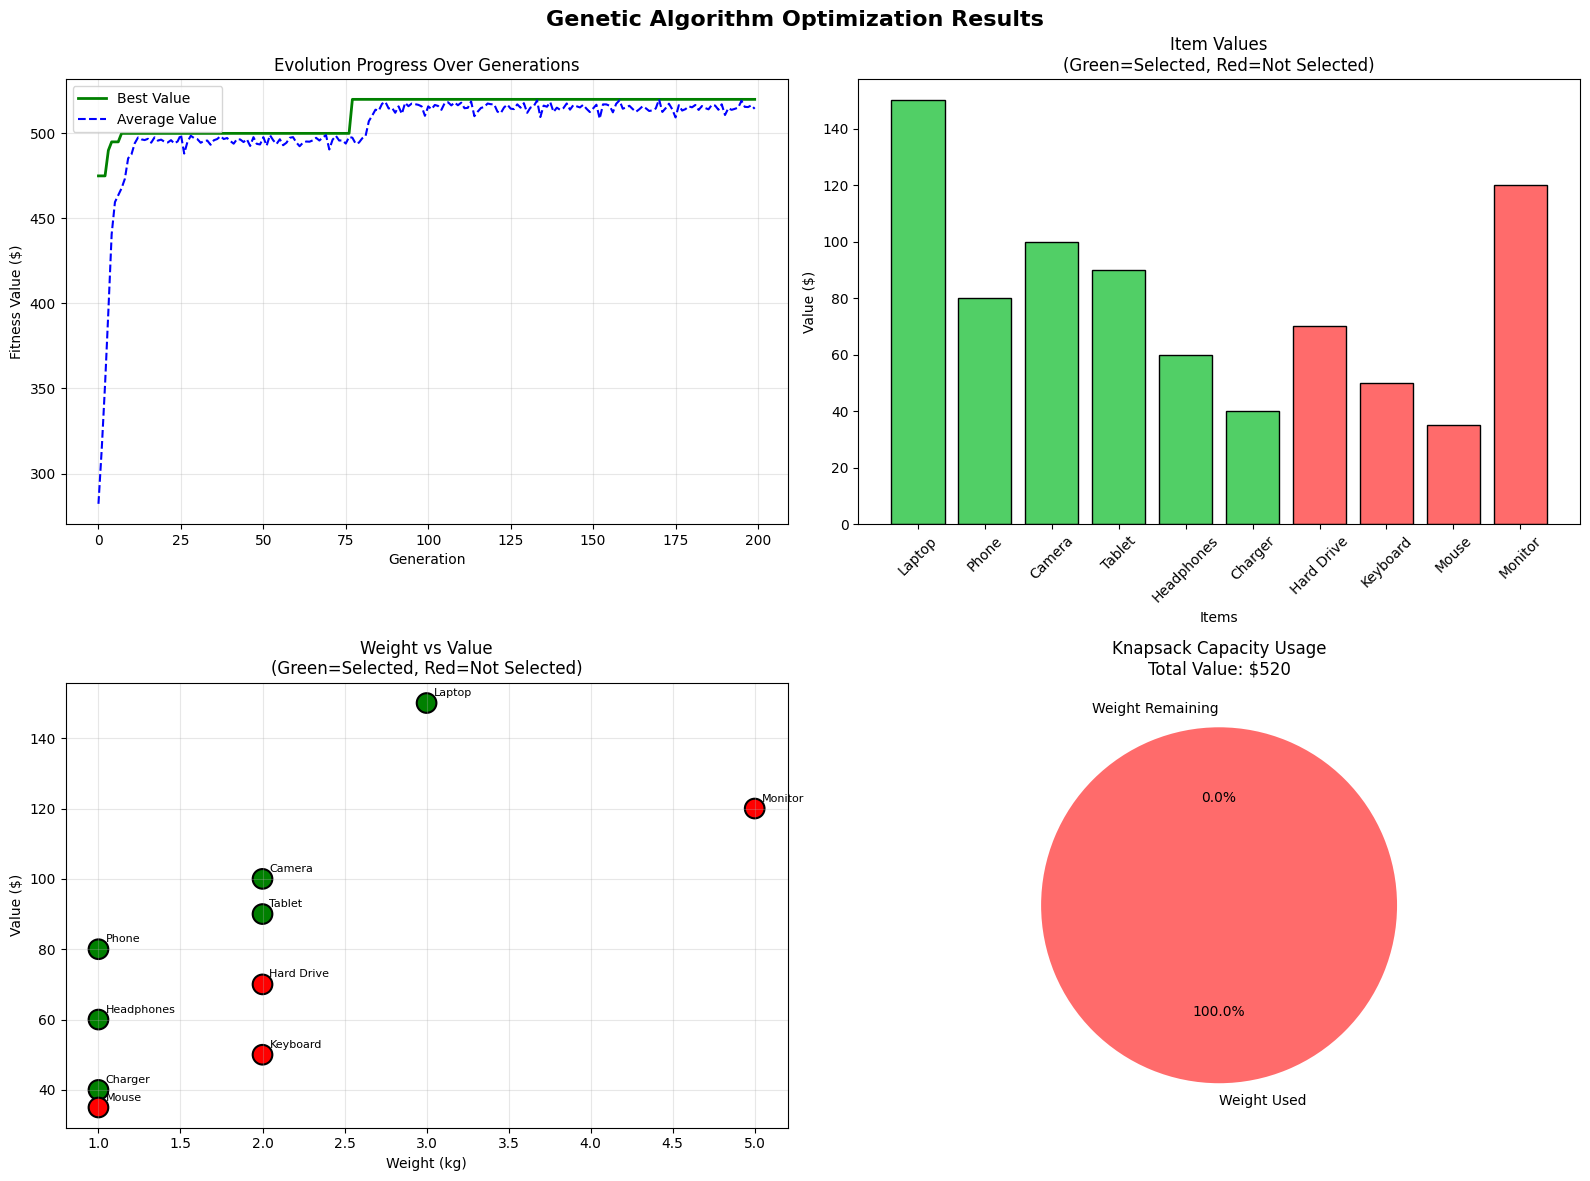

Visualization saved!

EVOLUTION SUMMARY
Generation 1   Best Value: $475
Generation 50  Best Value: $500
Generation 100 Best Value: $520
Generation 150 Best Value: $520
Generation 200 Best Value: $520

Improvement from Gen 1 to Gen 200: $45

TASK 4 COMPLETE — FINAL SUMMARY
Problem:          Knapsack Optimization
Items Available:  10
Weight Limit:     10kg
Population Size:  100
Generations:      200
Mutation Rate:    0.01
Items Selected:   6
Total Weight:     10kg
Optimal Value:    $520

Task 4 Successfully Completed! 🧬


In [ ]:
# ============================================
# TASK 4 - GENETIC ALGORITHM FOR OPTIMIZATION
# Codtech Machine Learning Internship
# Problem: Knapsack Optimization
# Objective: Maximize value within weight limit
# ============================================

# STEP 1 - IMPORT LIBRARIES
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

print("="*55)
print("GENETIC ALGORITHM FOR KNAPSACK OPTIMIZATION")
print("="*55)

# ============================================
# STEP 2 - DEFINE THE PROBLEM
# ============================================

# 10 items with names, weights and values
items = [
    {"name": "Laptop",      "weight": 3,  "value": 150},
    {"name": "Phone",       "weight": 1,  "value": 80},
    {"name": "Camera",      "weight": 2,  "value": 100},
    {"name": "Tablet",      "weight": 2,  "value": 90},
    {"name": "Headphones",  "weight": 1,  "value": 60},
    {"name": "Charger",     "weight": 1,  "value": 40},
    {"name": "Hard Drive",  "weight": 2,  "value": 70},
    {"name": "Keyboard",    "weight": 2,  "value": 50},
    {"name": "Mouse",       "weight": 1,  "value": 35},
    {"name": "Monitor",     "weight": 5,  "value": 120},
]

# Knapsack weight limit
WEIGHT_LIMIT = 10

# Display items
print("\nAvailable Items:")
print(f"{'Item':<15} {'Weight':>8} {'Value':>8}")
print("-" * 33)
for item in items:
    print(f"{item['name']:<15} {item['weight']:>8}kg {item['value']:>7}$")
print(f"\nKnapsack Weight Limit: {WEIGHT_LIMIT}kg")
print(f"Total items available: {len(items)}")

# ============================================
# STEP 3 - GENETIC ALGORITHM SETUP
# ============================================

# GA Parameters
POPULATION_SIZE = 100    # number of solutions in each generation
GENERATIONS = 200        # number of evolution cycles
MUTATION_RATE = 0.01     # probability of random mutation
ELITE_SIZE = 10          # best solutions kept unchanged

n_items = len(items)
weights = [item["weight"] for item in items]
values = [item["value"] for item in items]

# ============================================
# STEP 4 - CORE GA FUNCTIONS
# ============================================

def create_individual():
    """Create a random solution (chromosome)
    Each position = 1 (take item) or 0 (leave item)"""
    return [random.randint(0, 1) for _ in range(n_items)]

def create_population(size):
    """Create initial population of random solutions"""
    return [create_individual() for _ in range(size)]

def calculate_fitness(individual):
    """Calculate how good a solution is
    Returns total value if within weight limit
    Returns 0 if overweight (invalid solution)"""
    total_weight = sum(individual[i] * weights[i]
                      for i in range(n_items))
    total_value = sum(individual[i] * values[i]
                     for i in range(n_items))

    # Penalize solutions that exceed weight limit
    if total_weight > WEIGHT_LIMIT:
        return 0
    return total_value

def selection(population, fitnesses):
    """Select parent using tournament selection
    Pick 3 random individuals, return the best one"""
    tournament = random.sample(range(len(population)), 3)
    best = max(tournament, key=lambda x: fitnesses[x])
    return population[best]

def crossover(parent1, parent2):
    """Combine two parents to create two children
    Like biological reproduction"""
    if random.random() < 0.8:  # 80% chance of crossover
        # Single point crossover
        point = random.randint(1, n_items - 1)
        child1 = parent1[:point] + parent2[point:]
        child2 = parent2[:point] + parent1[point:]
        return child1, child2
    return parent1[:], parent2[:]

def mutate(individual):
    """Randomly flip bits in chromosome
    Like biological mutation"""
    mutated = individual[:]
    for i in range(n_items):
        if random.random() < MUTATION_RATE:
            mutated[i] = 1 - mutated[i]  # flip 0→1 or 1→0
    return mutated

def get_items_selected(individual):
    """Return list of selected items"""
    return [items[i]["name"] for i in range(n_items)
            if individual[i] == 1]

def get_total_weight(individual):
    """Return total weight of selected items"""
    return sum(individual[i] * weights[i] for i in range(n_items))

# ============================================
# STEP 5 - RUN THE GENETIC ALGORITHM
# ============================================

print("\n" + "="*55)
print("RUNNING GENETIC ALGORITHM...")
print("="*55)

# Initialize population
population = create_population(POPULATION_SIZE)

# Track progress
best_fitness_history = []
avg_fitness_history = []
best_solution = None
best_fitness = 0

# Evolution loop
for generation in range(GENERATIONS):

    # Calculate fitness for all individuals
    fitnesses = [calculate_fitness(ind) for ind in population]

    # Track best solution
    gen_best_fitness = max(fitnesses)
    gen_avg_fitness = np.mean([f for f in fitnesses if f > 0])

    best_fitness_history.append(gen_best_fitness)
    avg_fitness_history.append(gen_avg_fitness)

    # Update overall best solution
    if gen_best_fitness > best_fitness:
        best_fitness = gen_best_fitness
        best_solution = population[fitnesses.index(gen_best_fitness)]

    # Print progress every 50 generations
    if generation % 50 == 0:
        print(f"Generation {generation:3d}: "
              f"Best Value = ${gen_best_fitness}, "
              f"Avg Value = ${gen_avg_fitness:.1f}")

    # Create new population
    # Sort by fitness (elitism - keep best solutions)
    sorted_pop = [x for _, x in sorted(
        zip(fitnesses, population),
        key=lambda pair: pair[0], reverse=True)]

    new_population = sorted_pop[:ELITE_SIZE]  # keep elite

    # Fill rest with offspring
    while len(new_population) < POPULATION_SIZE:
        parent1 = selection(population, fitnesses)
        parent2 = selection(population, fitnesses)
        child1, child2 = crossover(parent1, parent2)
        child1 = mutate(child1)
        child2 = mutate(child2)
        new_population.extend([child1, child2])

    population = new_population[:POPULATION_SIZE]

print(f"\nEvolution complete after {GENERATIONS} generations!")

# ============================================
# STEP 6 - DISPLAY RESULTS
# ============================================

print("\n" + "="*55)
print("OPTIMAL SOLUTION FOUND")
print("="*55)

selected_items = get_items_selected(best_solution)
total_weight = get_total_weight(best_solution)
total_value = best_fitness

print(f"\nSelected Items:")
for item_name in selected_items:
    item = next(i for i in items if i["name"] == item_name)
    print(f"  ✅ {item['name']:<15} "
          f"Weight: {item['weight']}kg  "
          f"Value: ${item['value']}")

print(f"\nTotal Weight: {total_weight}kg / {WEIGHT_LIMIT}kg limit")
print(f"Total Value:  ${total_value}")
print(f"Weight Used:  {(total_weight/WEIGHT_LIMIT)*100:.1f}%")

# Compare with random solution
random_solution = create_individual()
random_fitness = calculate_fitness(random_solution)
improvement = ((total_value - random_fitness) /
               max(random_fitness, 1)) * 100

print(f"\nRandom solution value:  ${random_fitness}")
print(f"GA optimized value:     ${total_value}")
print(f"Improvement:            {improvement:.1f}% better!")

# ============================================
# STEP 7 - VISUALIZATIONS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Genetic Algorithm Optimization Results',
             fontsize=16, fontweight='bold')

# Chart 1 - Evolution progress
axes[0, 0].plot(best_fitness_history,
                color='green', linewidth=2,
                label='Best Value')
axes[0, 0].plot(avg_fitness_history,
                color='blue', linewidth=1.5,
                linestyle='--', label='Average Value')
axes[0, 0].set_title('Evolution Progress Over Generations')
axes[0, 0].set_xlabel('Generation')
axes[0, 0].set_ylabel('Fitness Value ($)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Chart 2 - Selected vs not selected items
item_names = [item["name"] for item in items]
item_values = [item["value"] for item in items]
item_colors = ['#51cf66' if best_solution[i] == 1
               else '#ff6b6b' for i in range(n_items)]
bars = axes[0, 1].bar(item_names, item_values,
                       color=item_colors, edgecolor='black')
axes[0, 1].set_title('Item Values\n(Green=Selected, Red=Not Selected)')
axes[0, 1].set_xlabel('Items')
axes[0, 1].set_ylabel('Value ($)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Chart 3 - Weight vs Value scatter
item_weights_list = [item["weight"] for item in items]
scatter_colors = ['green' if best_solution[i] == 1
                  else 'red' for i in range(n_items)]
axes[1, 0].scatter(item_weights_list, item_values,
                    c=scatter_colors, s=200,
                    edgecolors='black', linewidth=1.5)
for i, item in enumerate(items):
    axes[1, 0].annotate(item["name"],
                         (item["weight"], item["value"]),
                         textcoords="offset points",
                         xytext=(5, 5), fontsize=8)
axes[1, 0].set_title('Weight vs Value\n(Green=Selected, Red=Not Selected)')
axes[1, 0].set_xlabel('Weight (kg)')
axes[1, 0].set_ylabel('Value ($)')
axes[1, 0].grid(True, alpha=0.3)

# Chart 4 - Knapsack capacity usage
categories = ['Weight Used', 'Weight Remaining']
values_pie = [total_weight, WEIGHT_LIMIT - total_weight]
colors_pie = ['#ff6b6b', '#51cf66']
axes[1, 1].pie(values_pie, labels=categories,
               colors=colors_pie, autopct='%1.1f%%',
               startangle=90)
axes[1, 1].set_title(f'Knapsack Capacity Usage\n'
                      f'Total Value: ${total_value}')

plt.tight_layout()
plt.savefig('genetic_algorithm_results.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved!")

# ============================================
# STEP 8 - GENERATION BY GENERATION ANALYSIS
# ============================================

print("\n" + "="*55)
print("EVOLUTION SUMMARY")
print("="*55)
print(f"Generation 1   Best Value: ${best_fitness_history[0]}")
print(f"Generation 50  Best Value: ${best_fitness_history[49]}")
print(f"Generation 100 Best Value: ${best_fitness_history[99]}")
print(f"Generation 150 Best Value: ${best_fitness_history[149]}")
print(f"Generation 200 Best Value: ${best_fitness_history[199]}")
print(f"\nImprovement from Gen 1 to Gen 200: "
      f"${best_fitness_history[199] - best_fitness_history[0]}")

# ============================================
# STEP 9 - FINAL SUMMARY
# ============================================

print("\n" + "="*55)
print("TASK 4 COMPLETE — FINAL SUMMARY")
print("="*55)
print(f"Problem:          Knapsack Optimization")
print(f"Items Available:  {len(items)}")
print(f"Weight Limit:     {WEIGHT_LIMIT}kg")
print(f"Population Size:  {POPULATION_SIZE}")
print(f"Generations:      {GENERATIONS}")
print(f"Mutation Rate:    {MUTATION_RATE}")
print(f"Items Selected:   {len(selected_items)}")
print(f"Total Weight:     {total_weight}kg")
print(f"Optimal Value:    ${total_value}")
print(f"\nTask 4 Successfully Completed! 🧬")